#HW 1: k-NN

## Data file
Before running, upload `wdbc.csv` (Wisconsin Breast Cancer Diagnostic dataset, no header row) to the notebook's working directory:
- **Google Colab**: click the folder icon in the left sidebar → upload icon → select `wdbc.csv`. It will be available at `/content/wdbc.csv` for that session (you'll need to re-upload if the runtime disconnects/resets).
- **Local Jupyter**: place `wdbc.csv` in the same folder as this notebook file.

Make sure the filename/path in the `pd.read_csv(...)` call matches wherever you've placed the file.

## How to run
- Restart the kernel and run all cells **top to bottom, in order**. Later cells depend on functions defined earlier (`normalize_data`, `get_vectorized_distance_matrix`, `predict_k`, `knn_classifier_optimized`), so running out of order will cause errors.

## Two implementations in this notebook
- **Optimized approach** (main implementation): precomputes distance matrices once per trial and reuses them across all values of k. This is what generates the results and plots used in the report.
- **Brute-force approach** (included for reference, not run by default): a separate, unoptimized implementation that recomputes distances for every k individually. It sits at the very end of the notebook, separated from the optimized approach by some empty code cells, and its code blocks are commented out by default. To run it, uncomment the last 6 commented code blocks at the end of the notebook.


# Reproducibility
`np.random.seed(42)` is set once at the top of `knn_classifier_optimized`, so re-running from a fresh kernel reproduces the same sequence of splits and results. No fixed `random_state` is used inside the per-trial loop, since each of the 20 trials needs an independent random split.

## Configurable options
- `knn_classifier_optimized(df, isNormalized=True)` — set `isNormalized=False` to reproduce the "no normalization" results.
- The function call for both the mentioned cases is already written. So, there is no need to explicitly change the parameter and re-run the cell.


In [23]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from collections import Counter

In [24]:
#load dataset
df = pd.read_csv("wdbc.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


OPTIMIZED APPROACH

In [25]:
k_values = [i for i in range(1, 52, 2)]

In [26]:
#min-max normalization
def normalize_data(X_train, X_test):
  min=X_train.min()
  max=X_train.max()

  X_train_normalized=(X_train-min)/(max-min)
  X_test_normalized=(X_test-min)/(max-min)

  return X_train_normalized, X_test_normalized

In [27]:
def plot_graph(k_values, mean_accs, stds, title):
  plt.errorbar(k_values, mean_accs, yerr = stds, fmt='o', capsize=5, ecolor='red')
  plt.plot(k_values, mean_accs, color='black')
  plt.xlabel("k")
  plt.ylabel("Accuracy")
  plt.title(title)
  plt.show()

In [28]:
def get_vectorized_distance_matrix(query_data, train_data):
  query_data = np.asarray(query_data, dtype = float)
  train_data = np.asarray(train_data, dtype = float)

  distance_matrix = np.zeros((len(query_data), len(train_data)))

  for i in range(len(query_data)):
    difference = query_data[i]-train_data
    squares = difference ** 2
    sums = np.sum(squares, axis = 1)
    distance_matrix[i] = np.sqrt(sums)

  return distance_matrix

In [29]:
def predict_k(distance_matrix, y_train, k_values):
  sorted_idxs_of_k = np.argsort(distance_matrix, axis = 1)

  predictions = {}

  for k in k_values:
    nearest_k = sorted_idxs_of_k[:, :k]
    labels = y_train[nearest_k]
    majority_vote = np.mean(labels, axis = 1)
    predictions[k] = (majority_vote > 0.5).astype(int)

  return predictions

In [30]:
def knn_classifier_optimized(df, isNormalized=True):
  np.random.seed(42)

  X = df.iloc[:, :-1]
  y = df.iloc[:, -1]

  k_values = [i for i in range(1, 52, 2)]
  train_acc = np.zeros((len(k_values), 20))
  test_acc = np.zeros((len(k_values), 20))

  for epoch in range(20):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #shuffling is already handled in train_test_split function
    if isNormalized:
      X_train, X_test = normalize_data(X_train, X_test)

    X_train = np.asarray(X_train, dtype = float)
    y_train = np.asarray(y_train, dtype = float)
    y_test = np.asarray(y_test, dtype = float)

    distance_matrix_train = get_vectorized_distance_matrix(X_train, X_train)
    distance_matrix_test = get_vectorized_distance_matrix(np.asarray(X_test), X_train)

    predictions_train = predict_k(distance_matrix_train, y_train, k_values)
    predictions_test = predict_k(distance_matrix_test, y_train, k_values)

    for index, k in enumerate(k_values):
      train_acc[index][epoch] = np.mean(predictions_train[k] == y_train)
      test_acc[index][epoch] = np.mean(predictions_test[k] == y_test)

  return np.mean(train_acc, axis = 1), np.mean(test_acc, axis = 1), np.std(train_acc, axis = 1), np.std(test_acc, axis = 1)


In [31]:
mean_train, mean_test, std_train, std_test = knn_classifier_optimized(df)

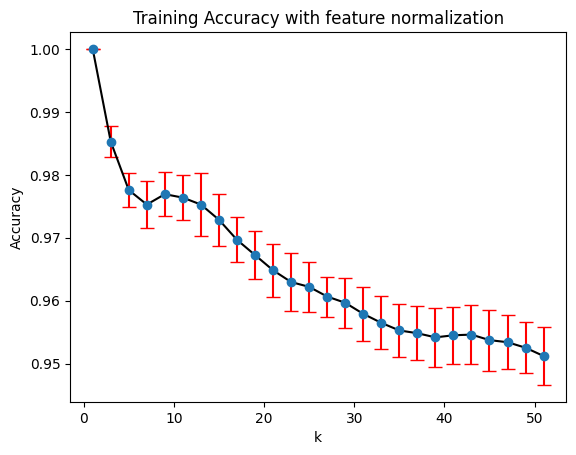

In [32]:
plot_graph(k_values, mean_train, std_train, "Training Accuracy with feature normalization")

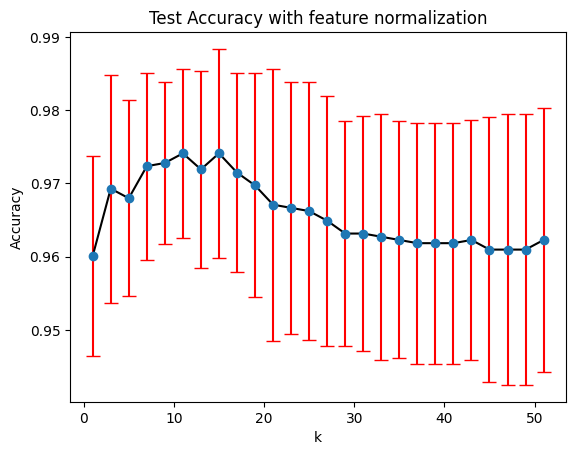

In [33]:
plot_graph(k_values, mean_test, std_test, "Test Accuracy with feature normalization")

In [34]:
mean_train_raw, mean_test_raw, std_train_raw, std_test_raw = knn_classifier_optimized(df, isNormalized=False)

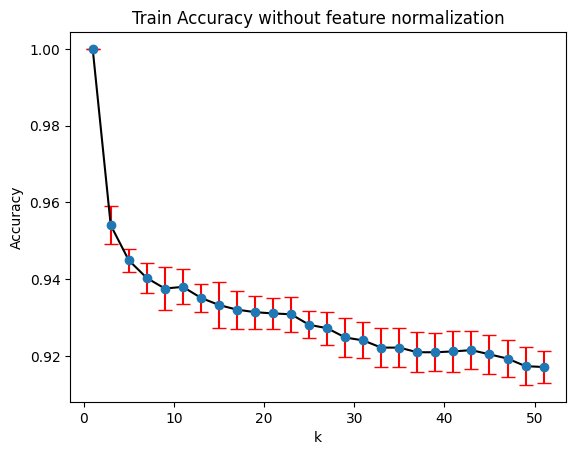

In [35]:
plot_graph(k_values, mean_train_raw, std_train_raw, "Train Accuracy without feature normalization")

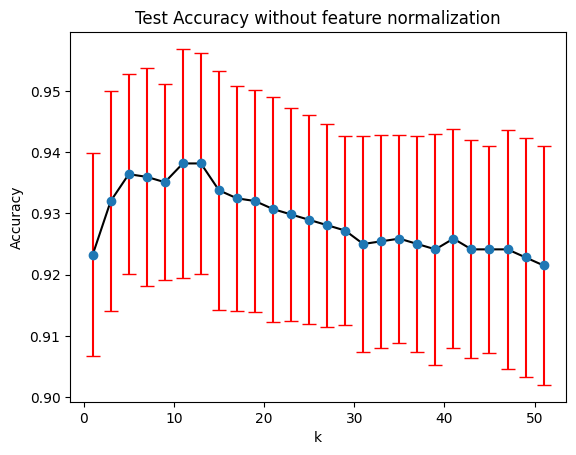

In [36]:
plot_graph(k_values, mean_test_raw, std_test_raw, "Test Accuracy without feature normalization")

BRUTE FORCE METHOD - TAKES LONGER TO EXECUTE
(Uncomment the last 6 code cells to execute this)

In [37]:
#shuffle and split
def shuffle_and_split(df):
  df_shuffled = shuffle(df) #didn't use random_state as we need uniquely shuffled and split datasets for all each value of k

  X=df_shuffled.iloc[:,:-1]
  y=df_shuffled.iloc[:,-1]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  return X_train, X_test, y_train, y_test

In [38]:
# computer euclidean distance
def compute_euclidean_distance(x1, x2):
  return np.sqrt(np.sum((x1-x2)**2))

#predict the labels
def predict(X_train, y_train, query_data, k):
  predictions=[]
  for x in np.array(query_data):
    distances=[compute_euclidean_distance(x, x_instance) for x_instance in np.array(X_train)]

    k_nearest_indices=np.argsort(distances)[:k] #argsort gives the indices of the sorted collection
    k_nearest_labels=[y_train.iloc[i] for i in k_nearest_indices]

    predictions.append(Counter(k_nearest_labels).most_common()[0][0])

  return predictions

# construct classifier
def knn_classifier(df, isNormalized=True):
  np.random.seed(42)

  k_values = [i for i in range(1, 52, 2)]

  mean_accs_train = []
  mean_accs_test = []
  stds_train = []
  stds_test = []

  X=df.iloc[:,:-1]
  y=df.iloc[:,-1]
  #breakpoint()
  for k in k_values:
    accuracy_train_list =[]
    accuracy_test_list=[]

    for i in range(20):
      X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #shuffling is already handled in train_test_split function

      # normalization
      #breakpoint()
      if isNormalized:
        X_train, X_test = normalize_data(X_train, X_test)

      #breakpoint()
      predictions_train = predict(X_train, y_train, X_train, k)
      predictions_test = predict(X_train, y_train, X_test, k)
      #breakpoint()
      accuracy_train=np.sum(np.array(predictions_train)==y_train)/len(y_train)
      accuracy_test=np.sum(np.array(predictions_test)==y_test)/len(y_test)
      #breakpoint()
      accuracy_train_list.append(accuracy_train)
      accuracy_test_list.append(accuracy_test)

    mean_accs_train.append(np.mean(accuracy_train_list))
    mean_accs_test.append(np.mean(accuracy_test_list))

    stds_train.append(np.std(accuracy_train_list))
    stds_test.append(np.std(accuracy_test_list))

  return mean_accs_train, mean_accs_test, stds_train, stds_test

In [39]:
#mean_accs_train_normalized, mean_accs_test_normalized, stds_train_normalized, stds_test_normalized = knn_classifier(df);

In [40]:
#plot_graph(k_values, mean_accs_train_normalized, stds_train_normalized, "Training Accuracy with feature normalization")

In [41]:
#plot_graph(k_values, mean_accs_test_normalized, stds_test_normalized, "Test Accuracy with feature normalization")

In [42]:
#mean_accs_train, mean_accs_test, stds_train, stds_test = knn_classifier(df, isNormalized=False);

In [43]:
#plot_graph(k_values, mean_accs_train, stds_train, "Training Accuracy w/o feature normalization")

In [44]:
#plot_graph(k_values, mean_accs_test, stds_test, "Test Accuracy - w/o feature normalization")